# Task 3.1.3: Multi-label Clothing Classification using EfficientNet-B0 trained from scratch.

## Environment Setup & Imports

In [1]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from sklearn.metrics import precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from tqdm import tqdm

# Set device for Kaggle T4 x2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Configuration & Global Constants

In [2]:
LABEL_MAP = {
    "short sleeve top": 0,
    "trousers": 1,
    "shorts": 2,
    "long sleeve top": 3,
    "skirt": 4
}
INV_LABEL_MAP = {v: k for k, v in LABEL_MAP.items()}

TRAIN_DIR = "/kaggle/input/datasets/shubhranilbasak/vr-trimmed-dataset/Trimmed-vr-dataset/DeepFashion2_Top5_train"
VAL_DIR = "/kaggle/input/datasets/shubhranilbasak/vr-trimmed-dataset/Trimmed-vr-dataset/DeepFashion2_Top5_val"

# Hyperparameters consistent with ResNet-50
IMG_SIZE = 224
BATCH_SIZE = 64 
EPOCHS = 30
LEARNING_RATE = 1e-4
PATIENCE = 5 

# Class Weights to handle imbalance 
class_counts = np.array([71645, 55387, 36616, 36064, 30835])
total_samples = np.sum(class_counts)
CLASS_WEIGHTS = torch.tensor(total_samples / (5 * class_counts), dtype=torch.float).to(device)

## Data Augmentation (Consistent Pipeline)

In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

## Dataset and Dataloaders

In [4]:
class DeepFashion2MultiLabel(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_dir = os.path.join(root_dir, "images")
        self.anno_dir = os.path.join(root_dir, "annos")
        self.filenames = [f.replace('.json', '') for f in os.listdir(self.anno_dir) if f.endswith('.json')]
        self.transform = transform

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx] + ".jpg"
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert("RGB")
        
        anno_path = os.path.join(self.anno_dir, self.filenames[idx] + ".json")
        with open(anno_path, 'r') as f:
            anno = json.load(f)

        target = np.zeros(5, dtype=np.float32)
        for key in anno.keys():
            if key.startswith('item'):
                cat_name = anno[key]['category_name']
                if cat_name in LABEL_MAP:
                    target[LABEL_MAP[cat_name]] = 1.0

        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(target)

train_dataset = DeepFashion2MultiLabel(TRAIN_DIR, transform=train_transforms)
val_dataset = DeepFashion2MultiLabel(VAL_DIR, transform=val_transforms)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

## EfficientNet-B0 Model from Scratch

In [5]:
def get_efficientnet_scratch():
    # 'weights=None' ensures training from scratch 
    model = models.efficientnet_b0(weights=None)
    
    # EfficientNet-B0 uses a 'classifier' block instead of 'fc'
    num_ftrs = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(num_ftrs, 5) 
    
    return model.to(device)

model = get_efficientnet_scratch()
# Using BCEWithLogitsLoss for multi-label classification [cite: 61]
criterion = nn.BCEWithLogitsLoss(pos_weight=CLASS_WEIGHTS)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

## Training with Early Stopping

In [6]:
best_val_loss = float('inf')
early_stop_counter = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for images, targets in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, targets in val_loader:
            images, targets = images.to(device), targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            val_loss += loss.item()

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'efficientnet_b0_scratch_best.pth')
        early_stop_counter = 0
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print("Early stopping triggered.")
            break

Epoch 1/30: 100%|██████████| 2253/2253 [18:23<00:00,  2.04it/s]


Train Loss: 0.5932, Val Loss: 0.5643


Epoch 2/30: 100%|██████████| 2253/2253 [13:04<00:00,  2.87it/s]


Train Loss: 0.5145, Val Loss: 0.4823


Epoch 3/30: 100%|██████████| 2253/2253 [12:15<00:00,  3.06it/s]


...

Train Loss: 0.2244, Val Loss: 0.3512


Epoch 26/30: 100%|██████████| 2253/2253 [12:17<00:00,  3.05it/s]


Train Loss: 0.2191, Val Loss: 0.3342


Epoch 27/30: 100%|██████████| 2253/2253 [12:18<00:00,  3.05it/s]


Train Loss: 0.2140, Val Loss: 0.3662
Early stopping triggered.


## Evaluation and Metrics

In [7]:
model.load_state_dict(torch.load('efficientnet_b0_scratch_best.pth'))
model.eval()

all_targets, all_preds, all_probs = [], [], []

with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        preds = (probs > 0.5).astype(float)
        all_targets.extend(targets.numpy())
        all_preds.extend(preds)
        all_probs.extend(probs)

all_targets, all_preds, all_probs = np.array(all_targets), np.array(all_preds), np.array(all_probs)

precision, recall, f1, _ = precision_recall_fscore_support(all_targets, all_preds, average=None)
macro_f1 = precision_recall_fscore_support(all_targets, all_preds, average='macro')[2]
micro_f1 = precision_recall_fscore_support(all_targets, all_preds, average='micro')[2]

print(f"{'Category':<20} | Precision | Recall | F1-Score")
print("-" * 50)
for i, name in INV_LABEL_MAP.items():
    print(f"{name:<20} | {precision[i]:.4f}    | {recall[i]:.4f} | {f1[i]:.4f}")
print("-" * 50)
print(f"Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}")

Evaluating: 100%|██████████| 371/371 [01:23<00:00,  4.43it/s]

Category             | Precision | Recall | F1-Score
--------------------------------------------------
short sleeve top     | 0.8822    | 0.7636 | 0.8186
trousers             | 0.8744    | 0.8722 | 0.8733
shorts               | 0.7565    | 0.7155 | 0.7354
long sleeve top      | 0.7122    | 0.6819 | 0.6967
skirt                | 0.7901    | 0.7444 | 0.7666
--------------------------------------------------
Macro F1: 0.7781 | Micro F1: 0.7957


## ROC Curves and AUC

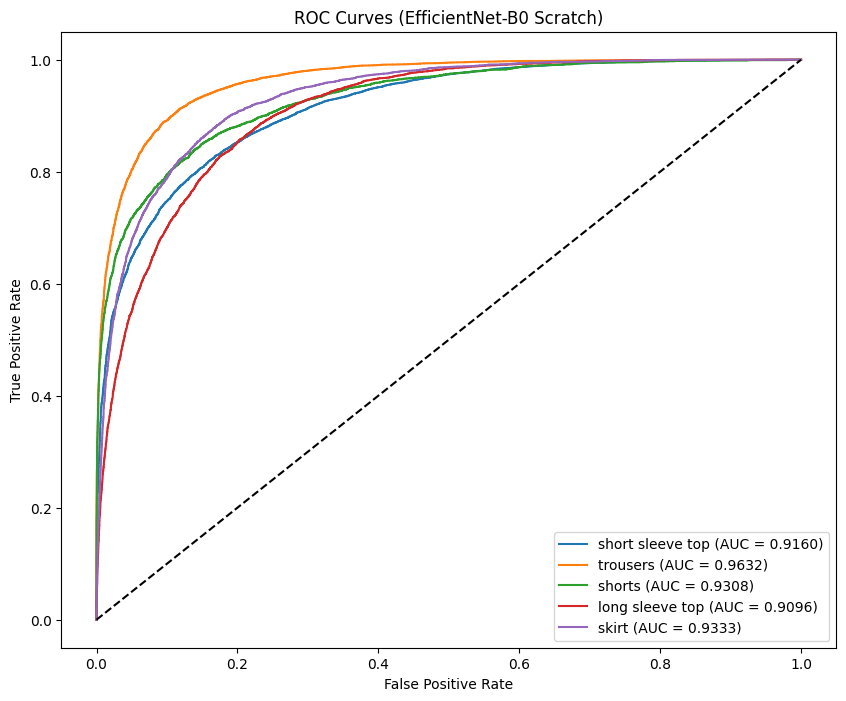

In [8]:
plt.figure(figsize=(10, 8))
for i, name in INV_LABEL_MAP.items():
    fpr, tpr, _ = roc_curve(all_targets[:, i], all_probs[:, i])
    auc_score = roc_auc_score(all_targets[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (EfficientNet-B0 Scratch)')
plt.legend()
plt.show()